# Распознавание геометрических форм фишек

## Цель работы

Разработать алгоритм компьютерного зрения, который обнаруживает на изображении игровые фишки и определяет их форму:

- круг;
- квадрат;
- шестигранник.

Содержимое, цвет, цифры и рисунки на фишках не используются как критерий классификации. Решение принимается по геометрии выделенной области.

Если фишки соприкасаются или частично перекрываются, алгоритм должен выделить границы каждой фишки отдельно и учесть их как разные объекты.

## Общая схема алгоритма

1. Загрузка исходного изображения.
2. Масштабирование до рабочего разрешения.
3. Сглаживание изображения для уменьшения мелкого цветового шума.
4. Сегментация методом k-means и построение маски объектов.
5. Разделение соприкасающихся объектов методом watershed.
6. Извлечение отдельных областей фишек.
7. Классификация формы по геометрическим признакам контура.
8. Масштабирование результатов к исходному разрешению.
9. Построение итогового изображения с границами и подписями.

## 1. Импорт библиотек и функций проекта

Реализация вынесена в пакет `src`:

- `io.py` — загрузка, масштабирование изображения и координат;
- `segmentation.py` — k-means и формирование маски фишек;
- `watershed.py` — разделение соприкасающихся объектов;
- `classification.py` — определение формы;
- `visualization.py` — построение итоговой разметки;
- `config.py` — параметры алгоритма.

In [ ]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

from src.classification import classify_regions
from src.config import PipelineConfig
from src.io import (
    load_image,
    resize_for_processing,
    resize_mask_to_shape,
    scale_prediction,
)
from src.segmentation import automatic_kmeans_mask
from src.filtering import filter_chip_regions
from src.visualization import draw_final_result
from src.watershed import (
    extract_watershed_regions,
    watershed_segmentation,
    colorize_markers,
)
from src.utils import show_image

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["font.size"] = 12

## 2. Настройка входного изображения и параметров

Путь `IMAGE_PATH` должен указывать на одно изображение из датасета.

Все параметры обработки собраны в объекте `PipelineConfig`. Это позволяет не хранить числовые пороги непосредственно в ячейках алгоритма и обеспечивает воспроизводимость эксперимента.

In [2]:
IMAGE_PATH = Path("./images/6.jpg")

config = PipelineConfig()

## 3. Загрузка исходного изображения

OpenCV считывает цветное изображение в формате BGR. Исходное изображение сохраняется без изменений: итоговая разметка будет построена именно на нём, чтобы не ухудшать качество результата при уменьшении изображения на промежуточных этапах.

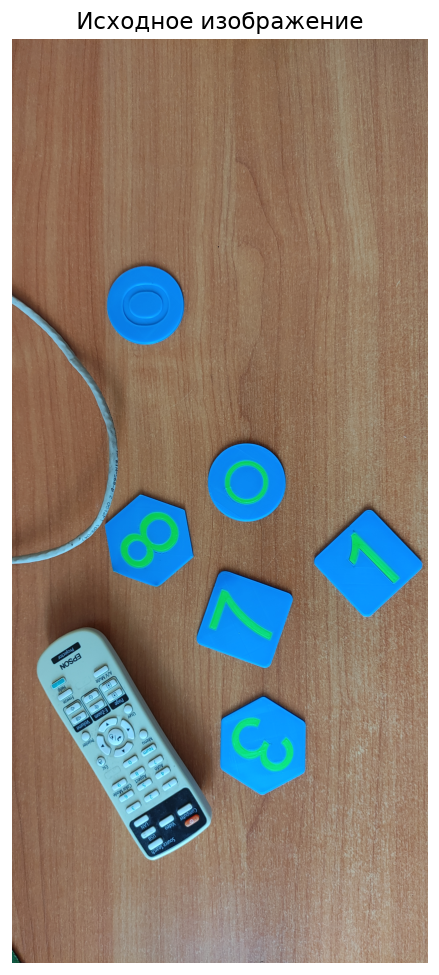

In [3]:
image_bgr = load_image(IMAGE_PATH)

show_image(
    image_bgr,
    title="Исходное изображение",
    figsize=(14, 10),
)

## 4. Подготовка изображения

Для снижения вычислительной нагрузки изображение при необходимости уменьшается до максимальной ширины, заданной в конфигурации.

После этого применяется гауссово сглаживание. Оно уменьшает влияние мелких деталей, надписей, текстур и шумов на кластеризацию цветов, но финальная разметка далее будет наложена на исходное изображение без размытия.

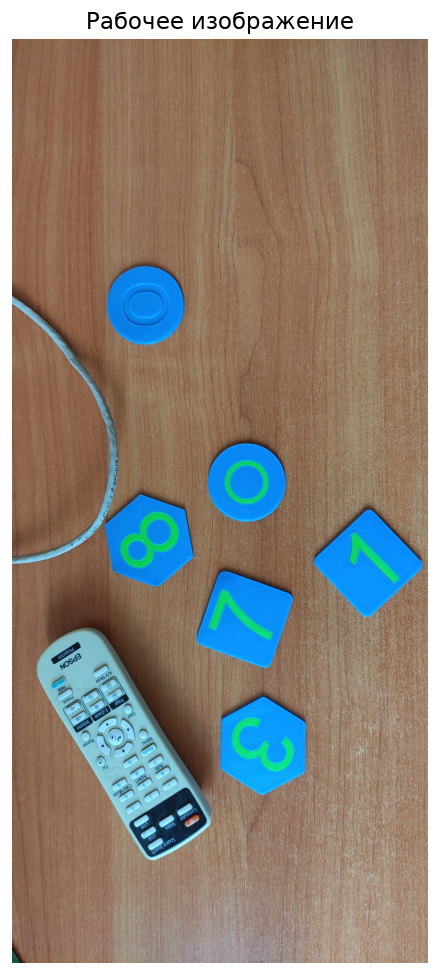

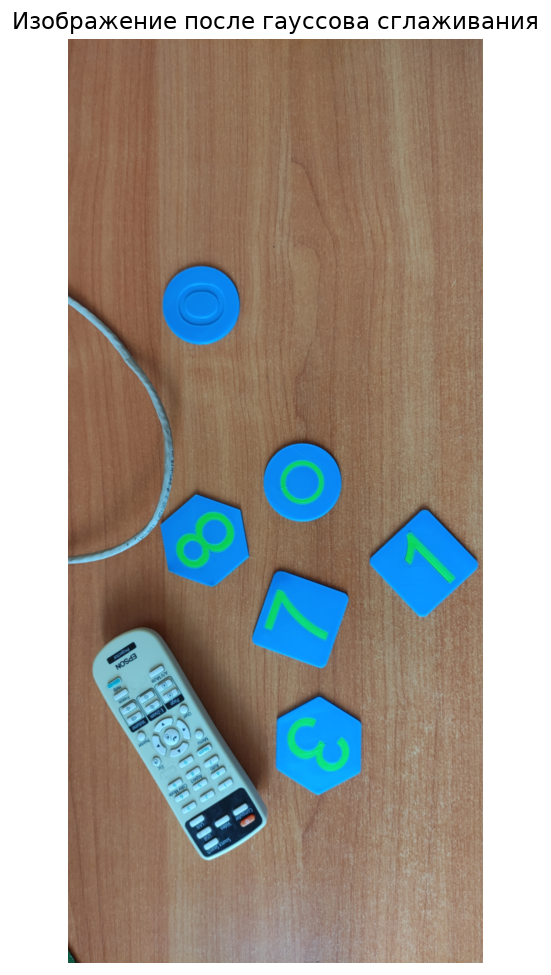

In [4]:
working_image_bgr = resize_for_processing(
    image_bgr,
    max_width=config.max_width,
)

processing_image_bgr = cv2.GaussianBlur(
    working_image_bgr,
    (5, 5),
    0,
)

show_image(
    working_image_bgr,
    title="Рабочее изображение",
    figsize=(14, 10),
)

show_image(
    processing_image_bgr,
    title="Изображение после гауссова сглаживания",
    figsize=(14, 10),
)

## 5. Формирование маски фишек методом k-means

Изображение разбивается на несколько цветовых кластеров методом k-means. Количество кластеров автоматически выбирается из диапазона `config.k_values`.

Фон определяется по кластерам, которые существенно представлены на границе изображения. Все остальные кластеры считаются кандидатами в передний план. Затем маска очищается морфологическими операциями и заполняется внутри объектов.

Таким образом, цифры, рисунки и небольшие элементы внутри фишек не должны создавать отдельные объекты.

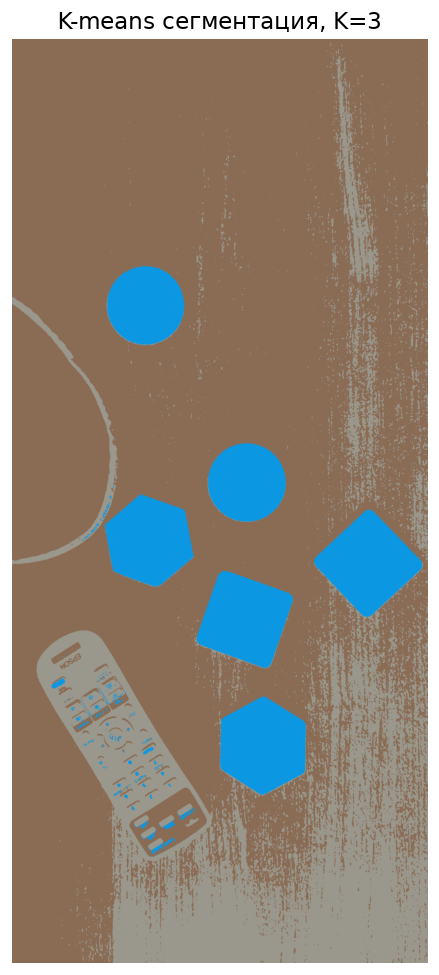

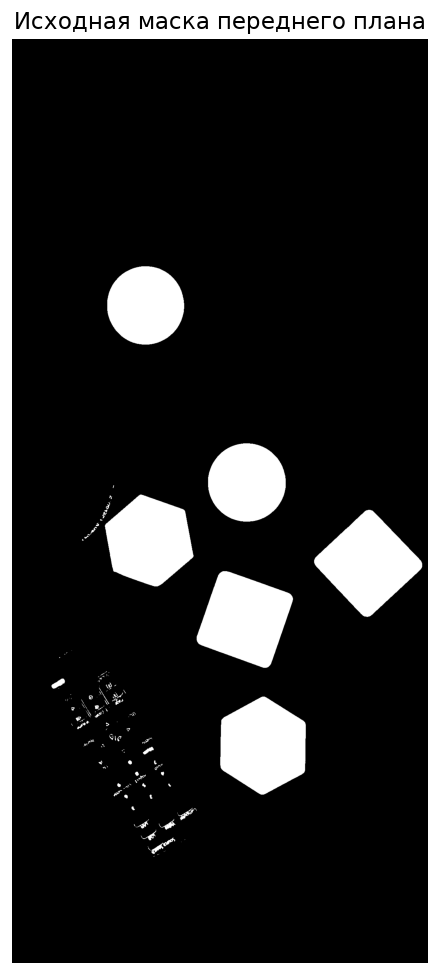

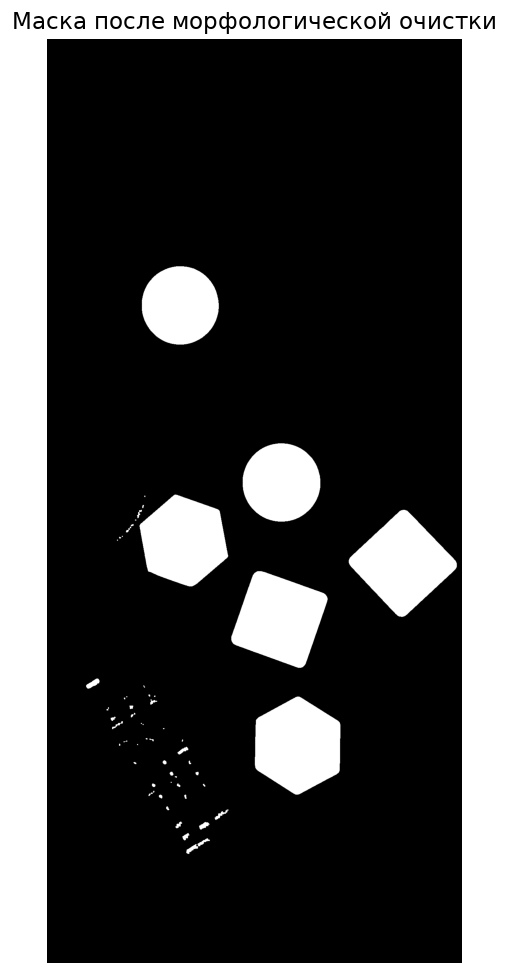

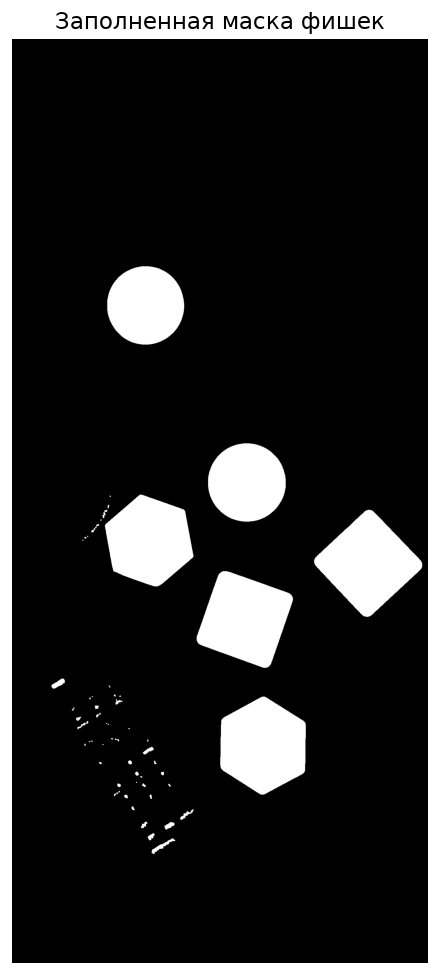

In [ ]:
best_mask_result, _ = automatic_kmeans_mask(
    processing_image_bgr,
    k_values=config.k_values,
    attempts=config.kmeans_attempts,
    seed=config.kmeans_seed,
    border_width=config.border_width,
    min_border_fraction=config.min_border_fraction,
    kernel_size=config.morphology_kernel_size,
    open_iterations=config.open_iterations,
    close_iterations=config.close_iterations,
    min_component_area=config.min_component_area,
)

segmented_image_bgr = best_mask_result["segmented"]
foreground_mask = best_mask_result["foreground_mask"]
cleaned_mask = best_mask_result["cleaned_mask"]
filled_mask = best_mask_result["filled_mask"]

show_image(
    segmented_image_bgr,
    title=f"K-means сегментация, K={best_mask_result['k']}",
    figsize=(14, 10),
)

show_image(
    foreground_mask,
    title="Исходная маска переднего плана",
    cmap="gray",
    figsize=(14, 10),
)

show_image(
    cleaned_mask,
    title="Маска после морфологической очистки",
    cmap="gray",
    figsize=(14, 10),
)

show_image(
    filled_mask,
    title="Заполненная маска фишек",
    cmap="gray",
    figsize=(14, 10),
)

## 6. Разделение соприкасающихся фишек методом watershed

Полученная бинарная маска может содержать несколько касающихся фишек как одну общую область. Для разделения таких объектов применяется watershed.

Сначала по маске строится distance transform. Затем из уверенных внутренних областей фишек формируются маркеры, по которым watershed разделяет общую область на отдельные регионы.

Этот этап необходим, чтобы фишки, лежащие друг на друге или соприкасающиеся краями, были учтены как разные объекты.

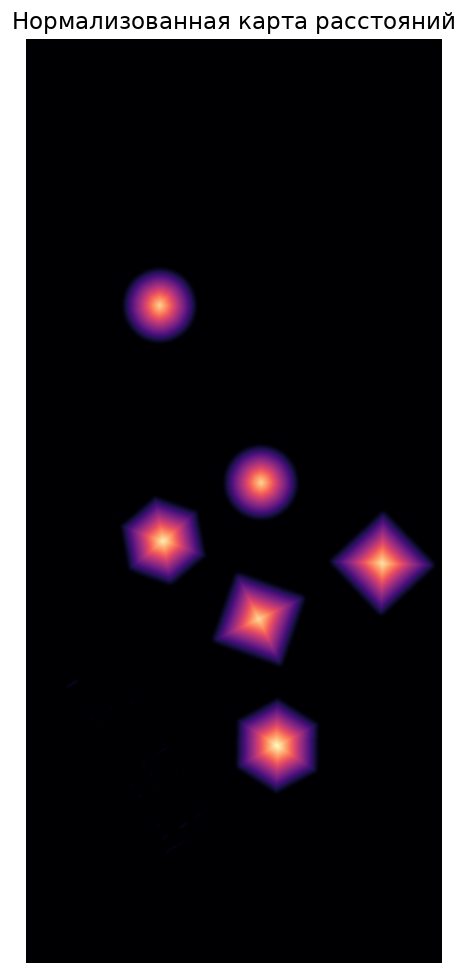

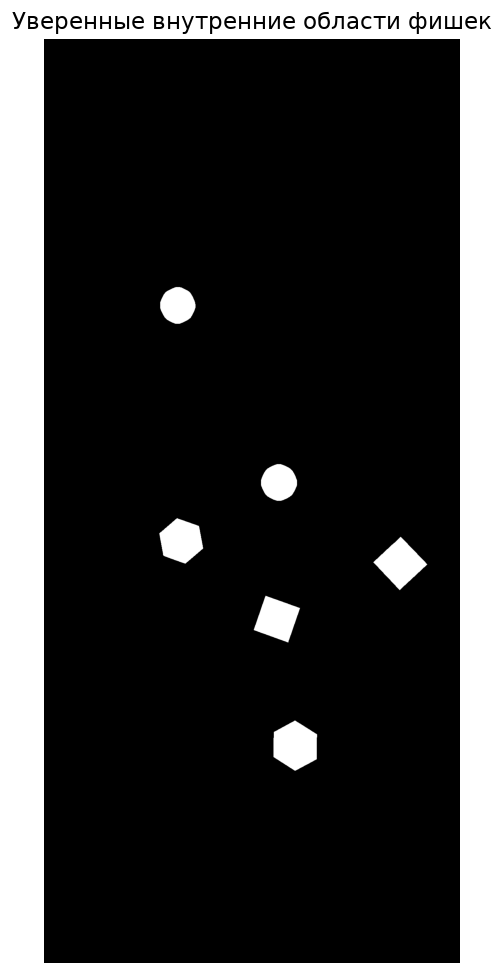

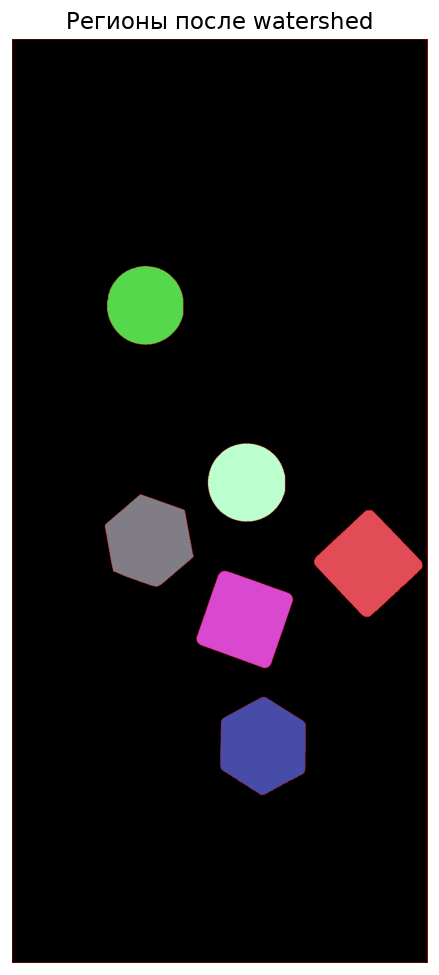

In [6]:
watershed_result = watershed_segmentation(
    working_image_bgr,
    filled_mask,
    distance_threshold=config.distance_threshold,
    dilation_iterations=config.dilation_iterations,
)

distance_normalized = watershed_result["distance_normalized"]
sure_foreground = watershed_result["sure_foreground"]
watershed_markers = watershed_result["watershed_markers"]
watershed_regions_bgr = colorize_markers(watershed_markers)

show_image(
    distance_normalized,
    title="Нормализованная карта расстояний",
    cmap="magma",
    figsize=(14, 10),
)

show_image(
    sure_foreground,
    title="Уверенные внутренние области фишек",
    cmap="gray",
    figsize=(14, 10),
)

show_image(
    watershed_regions_bgr,
    title="Регионы после watershed",
    figsize=(14, 10),
)

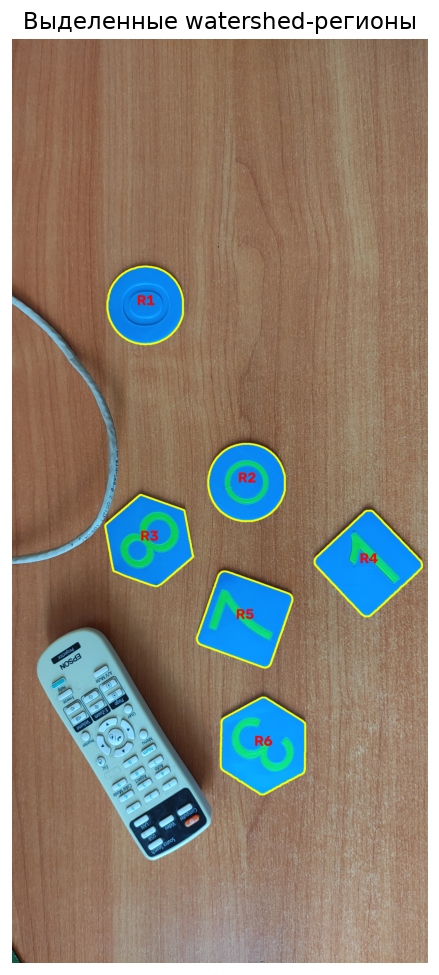

In [ ]:

regions = extract_watershed_regions(
    watershed_result["watershed_markers"],
    min_area=config.min_region_area,
)

regions = filter_chip_regions(
    regions,
    max_area_ratio=config.max_chip_area_ratio,
    max_aspect_ratio=config.max_chip_aspect_ratio,
)

regions_preview_bgr = working_image_bgr.copy()

for index, region in enumerate(regions, start=1):
    contour = region["contour"]
    center = tuple(np.round(region["center"]).astype(int))

    cv2.drawContours(
        regions_preview_bgr,
        [contour],
        contourIdx=-1,
        color=(0, 255, 255),
        thickness=4,
        lineType=cv2.LINE_AA,
    )

    cv2.putText(
        regions_preview_bgr,
        f"R{index}",
        (center[0] - 25, center[1]),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.4,
        (0, 0, 255),
        3,
        cv2.LINE_AA,
    )

show_image(
    regions_preview_bgr,
    title="Выделенные watershed-регионы",
    figsize=(14, 10),
)

## 7. Классификация формы фишек

Для каждой области, полученной после watershed, вычисляются геометрические признаки её выпуклой оболочки:

- число вершин аппроксимированного контура;
- круглотность;
- отношение сторон минимального ограничивающего прямоугольника;
- сходство с эталонами круга, квадрата и шестигранника по `cv2.matchShapes`.

Классификация основана на форме контура, а не на цвете, цифрах или рисунках на фишке.

In [8]:
predictions = classify_regions(
    regions,
    epsilon_ratio=config.approximation_epsilon_ratio,
)

for index, prediction in enumerate(predictions, start=1):
    features = prediction["features"]

    print(
        f"{index}. "
        f"shape={prediction['shape']}; "
        f"vertices={features['vertices']}; "
        f"circularity={features['circularity']:.3f}; "
        f"aspect_ratio={features['aspect_ratio']:.3f}; "
        f"confidence={prediction['confidence']:.2f}"
    )

1. shape=Circle; vertices=8; circularity=0.997; aspect_ratio=0.969; confidence=0.95
2. shape=Circle; vertices=8; circularity=0.998; aspect_ratio=0.987; confidence=0.99
3. shape=Hexagon; vertices=6; circularity=0.924; aspect_ratio=0.878; confidence=0.89
4. shape=Square; vertices=4; circularity=0.844; aspect_ratio=0.994; confidence=0.80
5. shape=Square; vertices=4; circularity=0.846; aspect_ratio=0.994; confidence=0.80
6. shape=Hexagon; vertices=6; circularity=0.931; aspect_ratio=0.875; confidence=0.94


## 8. Перенос результатов к исходному разрешению

Контуры и геометрические модели были найдены на рабочем уменьшенном изображении. Для получения качественного итогового изображения они масштабируются к размерам исходной фотографии.

Бинарная маска также масштабируется методом ближайшего соседа, чтобы сохранить её дискретную структуру.

In [9]:
predictions_original = [
    scale_prediction(
        prediction,
        source_shape=working_image_bgr.shape,
        target_shape=image_bgr.shape,
    )
    for prediction in predictions
]

chip_mask_original = resize_mask_to_shape(
    filled_mask,
    image_bgr.shape,
)

## 9. Построение итогового изображения

На итоговое изображение наносятся:

- светлая сплошная линия — фактически выделенная граница области после watershed;
- цветной пунктир — идеализированная модель распознанной геометрической фигуры;
- выноска с названием распознанной формы.

Положение выносок выбирается так, чтобы по возможности не пересекать другие подписи и не проводить линии через области фишек.

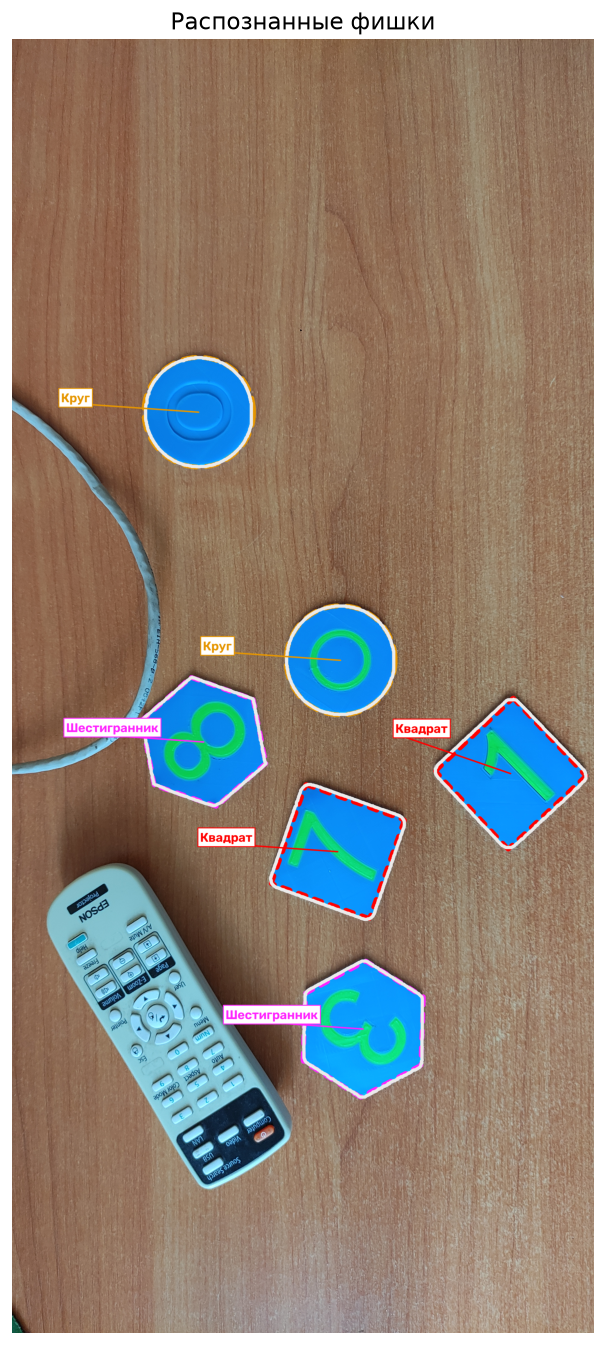

In [10]:
final_result_bgr = draw_final_result(
    image=image_bgr,
    predictions=predictions_original,
    chip_mask=chip_mask_original,
    observed_thickness=10,
    predicted_thickness=15,
    font_scale=1.55,
    text_thickness=4,
)

show_image(
    final_result_bgr,
    title="Распознанные фишки",
    figsize=(20, 14),
)